In [11]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from subprocess import check_output

In [12]:
CO2_df = pd.read_csv('./data/archive.csv')
temp_by_city = pd.read_csv('./data/ClimateChange/GlobalLandTemperaturesByCity.csv')
temp_by_country = pd.read_csv('./data/ClimateChange/TemperaturesByCountry.csv')
temp_by_major_city = pd.read_csv('./data/ClimateChange/TemperaturesByMajorCity.csv')
temp_by_state = pd.read_csv('./data/ClimateChange/TemperaturesByState.csv')
global_temp = pd.read_csv('./data/ClimateChange/GlobalTemperatures.csv')

In [3]:
CO2_df.head()

,Year,Month,Decimal Date,Carbon Dioxide (ppm),Seasonally Adjusted CO2 (ppm),Carbon Dioxide Fit (ppm),Seasonally Adjusted CO2 Fit (ppm)
0,1958,1,1958.0411,NaN,NaN,NaN,NaN
1,1958,2,1958.1260,NaN,NaN,NaN,NaN
2,1958,3,1958.2027,315.69,314.42,316.18,314.89
3,1958,4,1958.2877,317.45,315.15,317.30,314.98
4,1958,5,1958.3699,317.50,314.73,317.83,315.06


In [4]:
temp_by_city.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


In [5]:
temp_by_country.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


In [6]:
temp_by_major_city.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1849-01-01,26.704,1.435,Abidjan,Côte D'Ivoire,5.63N,3.23W
1,1849-02-01,27.434,1.362,Abidjan,Côte D'Ivoire,5.63N,3.23W
2,1849-03-01,28.101,1.612,Abidjan,Côte D'Ivoire,5.63N,3.23W
3,1849-04-01,26.140,1.387,Abidjan,Côte D'Ivoire,5.63N,3.23W
4,1849-05-01,25.427,1.200,Abidjan,Côte D'Ivoire,5.63N,3.23W


In [7]:
temp_by_state.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,State,Country
0,1855-05-01,25.544,1.171,Acre,Brazil
1,1855-06-01,24.228,1.103,Acre,Brazil
2,1855-07-01,24.371,1.044,Acre,Brazil
3,1855-08-01,25.427,1.073,Acre,Brazil
4,1855-09-01,25.675,1.014,Acre,Brazil


In [8]:
global_temp.head()

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Dropping all NaN values 
CO2_df = CO2_df.dropna()
temp_by_city = temp_by_city.dropna()
temp_by_country = temp_by_country.dropna()
temp_by_major_city = temp_by_major_city.dropna()
temp_by_state = temp_by_state.dropna()
global_temp = global_temp.dropna()

In [19]:
# Modify the date format so I could only use the year
def to_year(date):
    """
    returns year from date time
    """
    for i in [date]:
        first = i.split('-')[0]
        return int(first)
 
    
# Applying the date modification and creating a new column 
# in the dataset called year
temp_by_state['year'] = temp_by_state['dt'].apply(to_year)

# Collecting only data of the United States
dfs = temp_by_state[temp_by_state['Country'] == 'United States']

# Collecting the average temperature per year 
dfa = pd.DataFrame()
years = dfs['year'].unique()
for i in years:
    df_avg = dfs[dfs['year'] == i]['AverageTemperature'].mean()
    df_new = (dfs[dfs['year'] == i]).head(1)
    df_new['AverageTemperature'] = df_avg
    dfa = pd.concat([dfa, df_new], ignore_index=True) 

<Axes: xlabel='year', ylabel='AverageTemperature'>

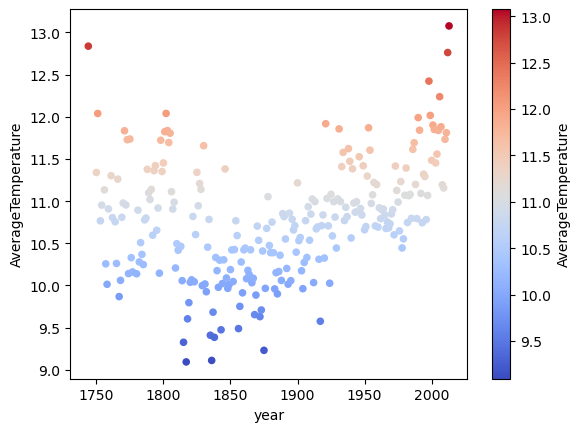

In [20]:
# Average Temperature above 9 degrees
df_nine = dfa[dfa['AverageTemperature'] >= 9]
df_nine.plot.scatter(x='year', y='AverageTemperature', c = 'AverageTemperature', cmap ='coolwarm')

<Axes: xlabel='year', ylabel='AverageTemperature'>

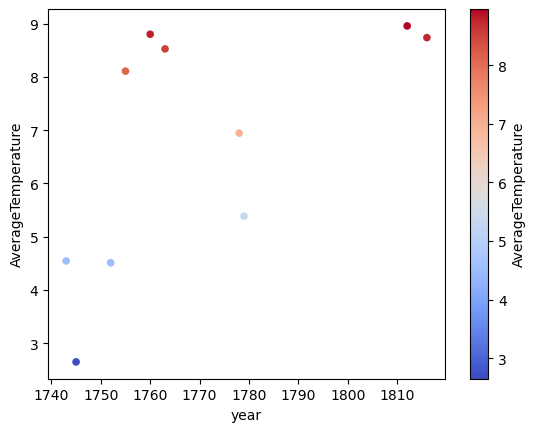

In [21]:
# Average Temperature below 9 degrees
df_nine = dfa[dfa['AverageTemperature'] <= 9]
df_nine.plot.scatter(x='year', y='AverageTemperature', c = 'AverageTemperature', cmap ='coolwarm')

In [22]:
new_co2_df = CO2_df

In [25]:
dfc = pd.DataFrame()

# Collecting all of the unique years
years = CO2_df['Year'].unique()

for i in years:
    df_avg = CO2_df[CO2_df['Year'] == i]['Carbon Dioxide (ppm)'].mean()
    df_new = CO2_df[CO2_df['Year'] == i].iloc[:1].copy()  # Use iloc for safe indexing
    df_new.loc[:, 'Carbon Dioxide (ppm)'] = df_avg  # Assign avg using loc
    dfc = pd.concat([dfc, df_new], ignore_index=True)  # Use pd.concat() instead of dfc.concat()

# Changing the Year column to year (lowercase)
dfc.rename(columns={"Year": "year"}, inplace=True)

# Dropping all of the unwanted columns
dfc.drop(columns=['Seasonally Adjusted CO2 (ppm)', 
                  'Carbon Dioxide Fit (ppm)', 
                  'Seasonally Adjusted CO2 Fit (ppm)',
                  'Decimal Date',
                  'Month'], inplace=True)

# Display the cleaned DataFrame
print(dfc)


    year  Carbon Dioxide (ppm)
0   1958            315.330000
1   1959            315.981667
2   1960            316.908333
3   1961            317.645000
4   1962            318.453333
5   1963            318.992500
6   1964            319.202222
7   1965            320.035833
8   1966            321.370000
9   1967            322.180000
10  1968            323.049167
11  1969            324.621667
12  1970            325.683333
13  1971            326.319167
14  1972            327.457500
15  1973            329.677500
16  1974            330.244167
17  1975            331.152500
18  1976            332.152500
19  1977            333.900833
20  1978            335.504167
21  1979            336.850833
22  1980            338.685000
23  1981            339.934167
24  1982            341.131667
25  1983            342.781667
26  1984            344.422500
27  1985            345.904167
28  1986            347.152500
29  1987            348.932500
30  1988            351.484167
31  1989

In [26]:
dfc = dfc.dropna()

C:\Drivers\Anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


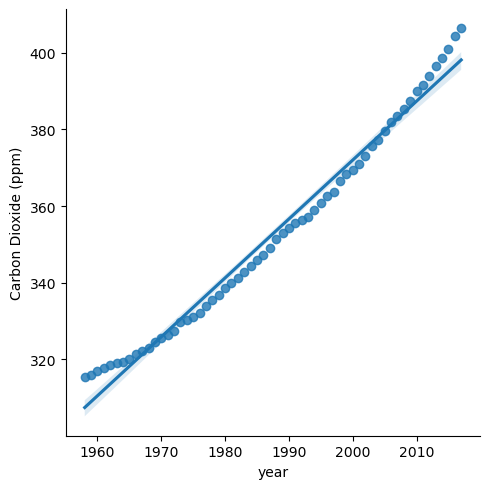

In [27]:
sns.lmplot(x='year', y='Carbon Dioxide (ppm)', data=dfc)

<Axes: >

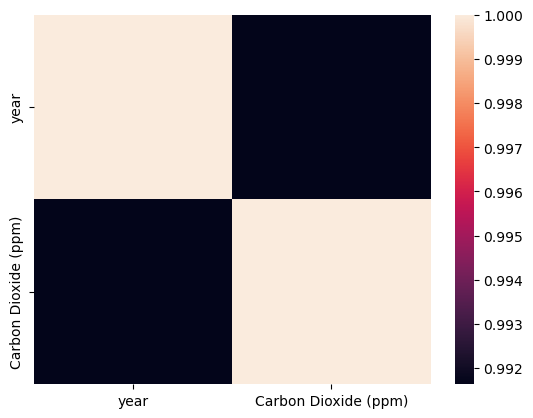

In [28]:
sns.heatmap(dfc.corr())

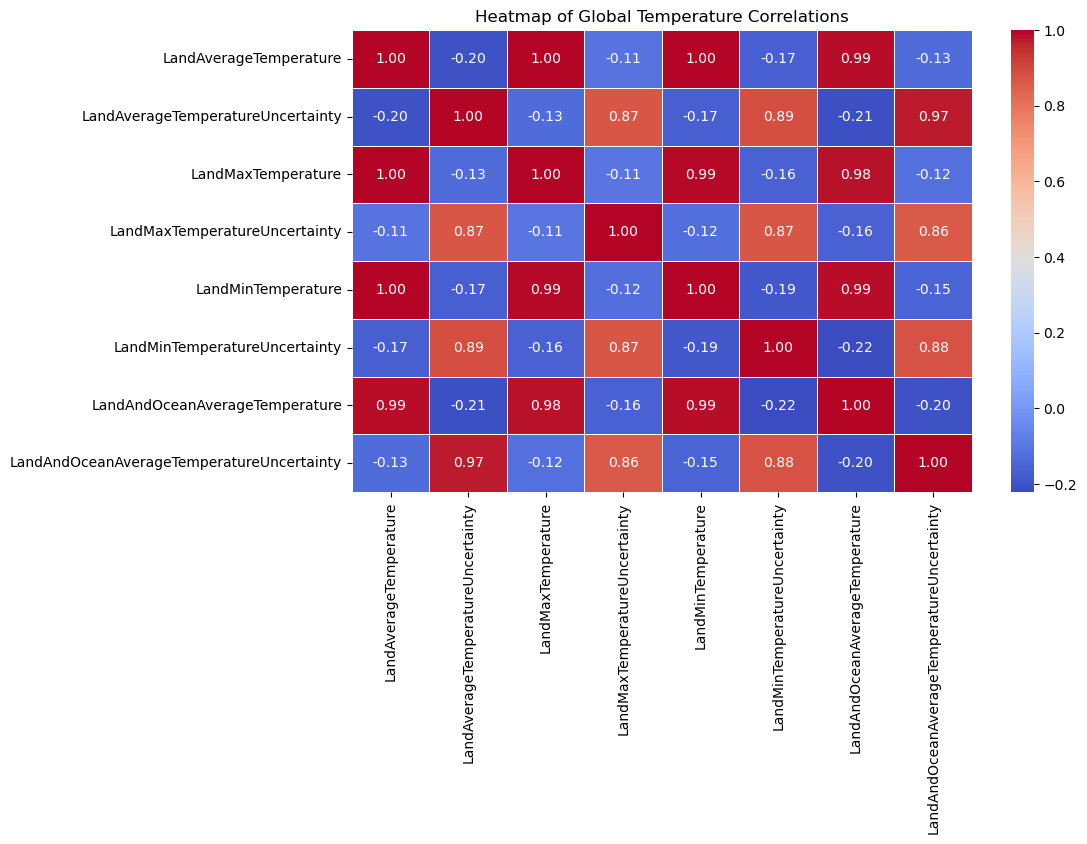

In [31]:
# Ensure numeric-only data for correlation
numeric_df = global_temp.select_dtypes(include=['number'])  # Select only numeric columns

# Compute and visualize the correlation matrix
plt.figure(figsize=(10, 6))  # Adjust figure size
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap of Global Temperature Correlations')
plt.show()

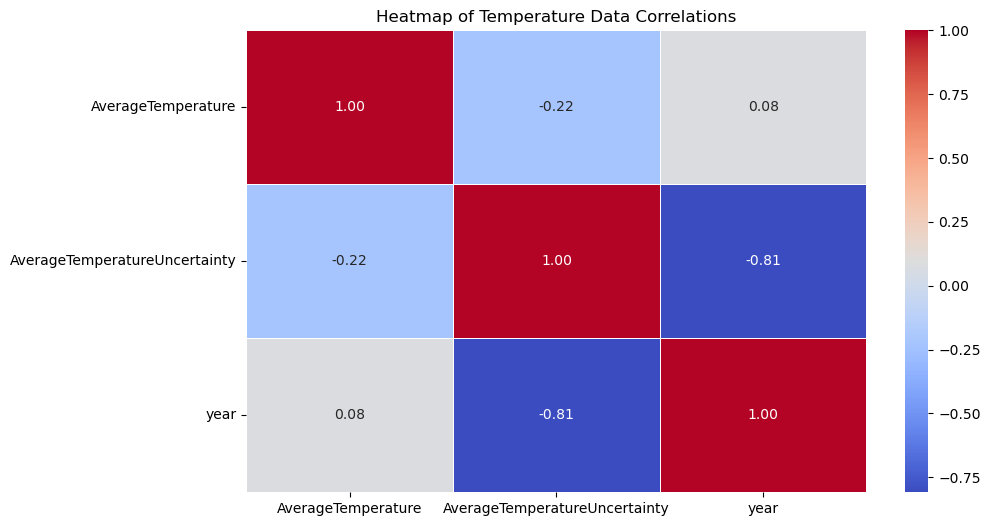

In [33]:
# Select only numeric columns for correlation
numeric_temp = temp_by_state.select_dtypes(include=['number'])

# Compute and visualize the correlation matrix
plt.figure(figsize=(10, 6))  # Set figure size
sns.heatmap(numeric_temp.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap of Temperature Data Correlations')
plt.show()

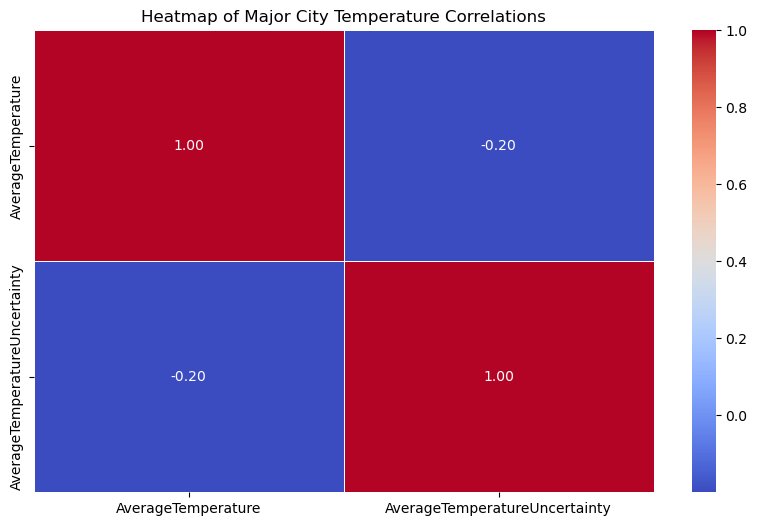

In [35]:
# Select only numeric columns for correlation
numeric_temp = temp_by_major_city.select_dtypes(include=['number'])

# Compute and visualize the correlation matrix
plt.figure(figsize=(10, 6))  # Set figure size
sns.heatmap(numeric_temp.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap of Major City Temperature Correlations')
plt.show()

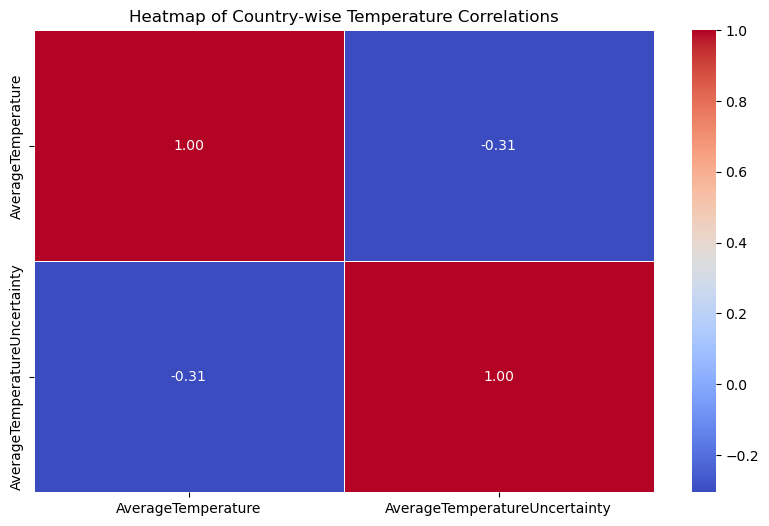

In [36]:
# Select only numeric columns for correlation
numeric_temp = temp_by_country.select_dtypes(include=['number'])

# Compute and visualize the correlation matrix
plt.figure(figsize=(10, 6))  # Adjust figure size
sns.heatmap(numeric_temp.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap of Country-wise Temperature Correlations')
plt.show()

In [37]:
CO2_df.rename(index=str, columns={"Year": "year"}, inplace=True)

In [38]:
dfsc = pd.merge(dfa, CO2_df, on=['year']).dropna()

dfsc.drop(['Seasonally Adjusted CO2 (ppm)', 
           'Carbon Dioxide Fit (ppm)', 
           'Seasonally Adjusted CO2 Fit (ppm)',
          'Decimal Date',
          'Month'], inplace=True, axis=1)

C:\Drivers\Anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


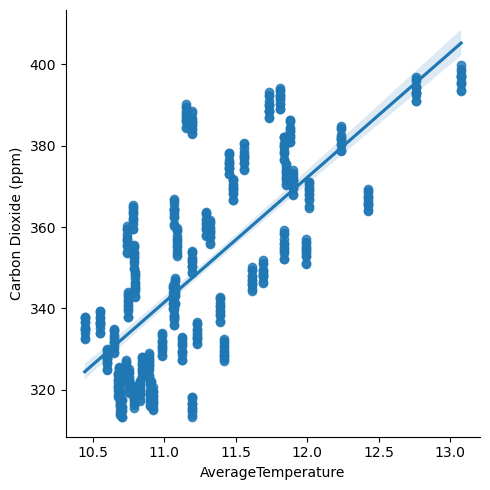

In [39]:
sns.lmplot(x='AverageTemperature', y='Carbon Dioxide (ppm)', data = dfsc)

In [47]:
# State that had the highest average temperature level
temp_by_state.loc[temp_by_state['AverageTemperature'].idxmax()]

dt                               2012-06-01
AverageTemperature                   36.339
AverageTemperatureUncertainty         0.385
State                                 Delhi
Country                               India
year                                   2012
Name: 116037, dtype: object

In [48]:
# Country that had the highest Average Temperature
# Kuwait (Western Asia)
temp_by_country.loc[temp_by_country['AverageTemperature'].idxmax()]

dt                               2012-07-01
AverageTemperature                   38.842
AverageTemperatureUncertainty         0.464
Country                              Kuwait
Name: 284851, dtype: object

In [49]:
temp_by_state.loc[temp_by_state['AverageTemperatureUncertainty'].idxmax()]

dt                                1768-01-01
AverageTemperature                    -9.102
AverageTemperatureUncertainty         12.646
State                            Kaliningrad
Country                               Russia
year                                    1768
Name: 202908, dtype: object

In [50]:
def mod_year(date):
    """
    returns year from date time
    """
    for i in [date]:
        first = i.split('-')[0]
        return int(first)

In [51]:
def mod_month(date):
    """
    returns month from date time
    """
    for i in [date]:
        second = i.split('-')[1]
        return int(second)

In [52]:
temp_by_country['year'] = temp_by_country['dt'].apply(mod_year)
temp_by_country['month'] = temp_by_country['dt'].apply(mod_month)

In [53]:
country_new_temp_data = pd.merge(temp_by_country, CO2_df, on=['year'])

In [65]:
import pandas as pd
import datetime as dt

# Assuming country_new_temp_data is already loaded

# Step 1: Check data types and unique values
print(country_new_temp_data.dtypes)
print(country_new_temp_data["Carbon Dioxide (ppm)"].head(10))
print(country_new_temp_data["Carbon Dioxide (ppm)"].unique())

# Step 2: Convert "Carbon Dioxide (ppm)" to numeric, forcing errors to NaN
country_new_temp_data["Carbon Dioxide (ppm)"] = pd.to_numeric(
    country_new_temp_data["Carbon Dioxide (ppm)"], errors="coerce"
)

# Step 3: Remove NaN values
country_new_temp_data.dropna(subset=["Carbon Dioxide (ppm)"], inplace=True)

# Step 4: Verify cleanup
print(country_new_temp_data["Carbon Dioxide (ppm)"].dtype)
print(country_new_temp_data["Carbon Dioxide (ppm)"].head(10))

# Step 5: Group by year and month, taking the mean
country_carbon = country_new_temp_data.groupby(["year", "month"]).mean(numeric_only=True)["Carbon Dioxide (ppm)"]

# Step 6: Create datetime objects for plotting
xx = [dt.datetime(year=i[0], month=i[1], day=15) for i in country_carbon.index]

# Step 7: Compute different moving averages
yy1 = country_carbon.values  # Original values
yy2 = country_carbon.rolling(3, min_periods=1).mean().values  # Rolling mean
yy3 = country_carbon.ewm(span=3, min_periods=1).mean().values  # Exponential moving average

# Final check
print(xx[:10], yy1[:10], yy2[:10], yy3[:10])  # Print first 10 values to verify


dt                                    object
AverageTemperature                   float64
AverageTemperatureUncertainty        float64
Country                               object
year                                   int64
month                                  int64
Month                                  int64
Decimal Date                         float64
Carbon Dioxide (ppm)                 float64
Seasonally Adjusted CO2 (ppm)        float64
Carbon Dioxide Fit (ppm)             float64
Seasonally Adjusted CO2 Fit (ppm)    float64
dtype: object
2     315.69
3     317.45
4     317.50
6     315.86
7     314.93
8     313.21
10    313.33
11    314.67
14    315.69
15    317.45
Name: Carbon Dioxide (ppm), dtype: float64
[315.69 317.45 317.5  315.86 314.93 313.21 313.33 314.67 315.58 316.48
 316.65 317.72 318.29 318.15 316.54 314.8  313.84 313.34 314.81 316.43
 316.97 317.58 319.03 320.03 319.59 318.18 315.9  314.17 313.83 315.
 316.19 316.9  317.7  318.54 319.48 320.58 319.77 318.57 316.7

In [66]:
second_country_trace = go.Scatter(x=xx, y=yy1, mode="markers", name="Actual value")
third_country_trace = go.Scatter(x=xx, y=yy2, line=dict(color="red"), name="Rolling average")
forth_country_trace = go.Scatter(x=xx, y=yy3, line=dict(color="green"), name="EWM average")

In [69]:
import numpy as np
import pandas as pd
import datetime as dt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Ensure numeric values and remove NaNs
country_new_temp_data["Carbon Dioxide (ppm)"] = pd.to_numeric(
    country_new_temp_data["Carbon Dioxide (ppm)"], errors="coerce"
)
country_new_temp_data.dropna(subset=["Carbon Dioxide (ppm)"], inplace=True)

# Group by year and month, taking the mean
country_carbon = country_new_temp_data.groupby(["year", "month"])["Carbon Dioxide (ppm)"].mean()

# Create datetime objects
x = [dt.datetime(year=i[0], month=i[1], day=15) for i in country_carbon.index]

# Mean values
y1 = country_carbon.values

# Convert to NumPy arrays
x_values = np.array([(i.year, i.month, i.month ** 2, i.year ** 2) for i in x])
y_values = np.array(y1)

# Print initial shapes
print("Original x_values shape:", x_values.shape)
print("Original y_values shape:", y_values.shape)

# Remove NaNs in y_values
valid_y_indices = ~np.isnan(y_values)
x_values = x_values[valid_y_indices]
y_values = y_values[valid_y_indices]

# Print new shapes
print("Filtered x_values shape:", x_values.shape)
print("Filtered y_values shape:", y_values.shape)

# Remove NaNs in x_values
valid_x_indices = ~np.isnan(x_values).any(axis=1)
x_values = x_values[valid_x_indices]
y_values = y_values[valid_x_indices]

# Print final shapes
print("Final x_values shape:", x_values.shape)
print("Final y_values shape:", y_values.shape)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x_values, y_values, test_size=0.40, random_state=45
)

# Train the model
linearModel = LinearRegression().fit(x_train, y_train)

# Print accuracy
print("Accuracy:", linearModel.score(x_test, y_test))

# Predicted values
pred_value = linearModel.predict(x_values)


Original x_values shape: (669, 4)
Original y_values shape: (669,)
Filtered x_values shape: (669, 4)
Filtered y_values shape: (669,)
Final x_values shape: (669, 4)
Final y_values shape: (669,)
Accuracy: 0.999344517086184


In [70]:
# country_new_temp_data['Country'].unique()
df1 = country_new_temp_data.groupby(['Country'])

In [71]:
df2= df1.apply(lambda x: x.sort_values(["Carbon Dioxide (ppm)"]))

In [72]:
df3=df2.reset_index(drop=True)
df3.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country,year,month,Month,Decimal Date,Carbon Dioxide (ppm),Seasonally Adjusted CO2 (ppm),Carbon Dioxide Fit (ppm),Seasonally Adjusted CO2 Fit (ppm)
0,1958-03-01,11.055,0.483,Afghanistan,1958,3,9,1958.7068,313.21,316.06,312.48,315.35
1,1958-07-01,27.240,0.363,Afghanistan,1958,7,9,1958.7068,313.21,316.06,312.48,315.35
2,1958-05-01,18.752,0.394,Afghanistan,1958,5,9,1958.7068,313.21,316.06,312.48,315.35
3,1958-08-01,24.639,0.436,Afghanistan,1958,8,9,1958.7068,313.21,316.06,312.48,315.35
4,1958-09-01,21.086,0.463,Afghanistan,1958,9,9,1958.7068,313.21,316.06,312.48,315.35
